In [43]:
pip install scikit-learn-extra

### **Paquetes Descriptivos**

In [44]:
import pandas as pd #para manipular y analizar datos
import numpy as np #para operaciones matematicas y estadisticas con los datos
import seaborn as sns #para visualizacion de datos (graficos)
import matplotlib.pyplot as plt #para visualizacion de datos (graficos)

from sklearn.metrics import pairwise_distances
from sklearn.datasets import make_blobs
from sklearn_extra.cluster import KMedoids
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [45]:
df= pd.read_excel('/content/7.1 ProductosCarnicos.xlsx')#, sheet_name=1)

In [46]:
print(df.head()) #como se ve nuestro df

   No. Nombre del Negocio      Localidad                       Barrio  \
0    1           Tienda 1  PUENTE ARANDA                 CUNDINAMARCA   
1    2           Tienda 2    TEUSAQUILLO  CIUDAD SALITRE SUR-ORIENTAL   
2    3           Tienda 3    TEUSAQUILLO                     PAULO VI   
3    4           Tienda 4       FONTIBON           LA ESPERANZA NORTE   
4    5           Tienda 5    TEUSAQUILLO                 LA ESMERALDA   

                  Tipo Tienda CanalAtencion  CantidadReferencias  \
0  Carniceria/Pesqueria/Fama       Vendedor                    2   
1  Carniceria/Pesqueria/Fama       Vendedor                    6   
2  Carniceria/Pesqueria/Fama   Telemercadeo                    7   
3  Carniceria/Pesqueria/Fama   Mercaderista                    5   
4  Carniceria/Pesqueria/Fama       Vendedor                    8   

   NivelSocioEconómico  CompraMes1  Antigüedad  CompraMes2  MtsCuadrados  \
0                    3      100000           0      143000            12   


In [47]:
df.info() # que tipo de variables tenemos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No.                  199 non-null    int64  
 1   Nombre del Negocio   199 non-null    object 
 2   Localidad            199 non-null    object 
 3   Barrio               199 non-null    object 
 4   Tipo Tienda          199 non-null    object 
 5   CanalAtencion        199 non-null    object 
 6   CantidadReferencias  199 non-null    int64  
 7   NivelSocioEconómico  199 non-null    int64  
 8   CompraMes1           199 non-null    int64  
 9   Antigüedad           199 non-null    int64  
 10  CompraMes2           199 non-null    int64  
 11  MtsCuadrados         199 non-null    int64  
 12  Utilidad             199 non-null    float64
 13  QTrabajadores        199 non-null    int64  
 14  TiendasCompetencia   199 non-null    int64  
dtypes: float64(1), int64(9), object(5)
memor

In [48]:
# Analisis de variables
df.describe(percentiles=[0.25, 0.5,0.75,0.8],include='all')


,No.,Nombre del Negocio,Localidad,Barrio,Tipo Tienda,CanalAtencion,CantidadReferencias,NivelSocioEconómico,CompraMes1,Antigüedad,CompraMes2,MtsCuadrados,Utilidad,QTrabajadores,TiendasCompetencia
count,199.0,199,199,199,199,199,199.0,199.0,199.0,199.0,199.0,199.0,199.0,199.0,199.0
unique,NaN,199,4,31,10,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Tienda 1,TEUSAQUILLO,QUINTA PAREDES,Tienda de Barrio,Vendedor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,112,23,39,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,100.0,NaN,NaN,NaN,NaN,NaN,7.3,3.2,483919.6,2.7,523824.1,22.9,0.1,2.3,1.9
std,57.6,NaN,NaN,NaN,NaN,NaN,4.7,1.1,283810.1,2.1,285104.7,7.6,0.0,1.0,1.4
min,1.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,100000.0,0.0,95000.0,12.0,0.0,1.0,0.0
25%,50.5,NaN,NaN,NaN,NaN,NaN,4.0,3.0,300000.0,1.0,323500.0,17.0,0.1,2.0,1.0
50%,100.0,NaN,NaN,NaN,NaN,NaN,6.0,4.0,400000.0,2.0,450000.0,21.0,0.1,2.0,2.0
75%,149.5,NaN,NaN,NaN,NaN,NaN,9.0,4.0,600000.0,4.0,653000.0,28.0,0.1,3.0,3.0


## **Análisis de Componentes principales**

In [49]:
# Selección variables Cuantitativas
column_names = ['CantidadReferencias',
                'NivelSocioEconómico',
                'CompraMes1',
                'Antigüedad',
                'CompraMes2',
                'MtsCuadrados',
                'Utilidad',
                'QTrabajadores',
                'TiendasCompetencia']
df_1 = df[column_names]
print(df_1.head())

   CantidadReferencias  NivelSocioEconómico  CompraMes1  Antigüedad  \
0                    2                    3      100000           0   
1                    6                    4      200000           1   
2                    7                    4      300000           4   
3                    5                    1      400000           6   
4                    8                    4      500000           2   

   CompraMes2  MtsCuadrados  Utilidad  QTrabajadores  TiendasCompetencia  
0      143000            12       0.1              2                   1  
1      279000            28       0.1              3                   4  
2      352000            22       0.1              2                   1  
3      426000            14       0.1              1                   0  
4      589000            21       0.1              3                   4  


In [50]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# Estandarizar los datos
scaler = StandardScaler()
df_1_scaled = scaler.fit_transform(df_1)

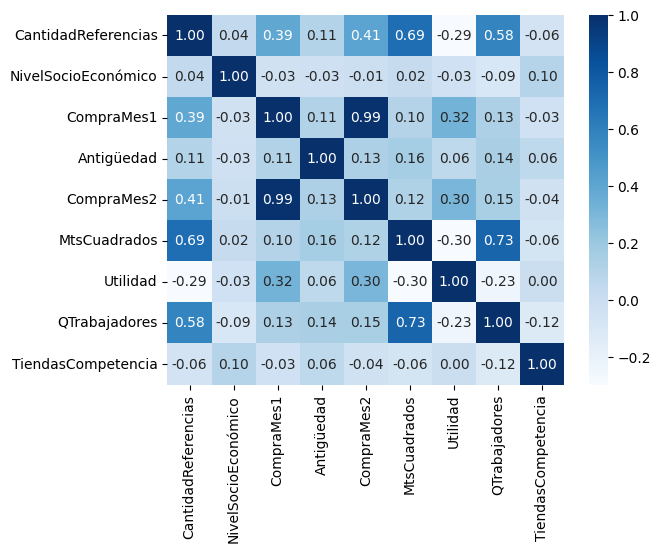

<Figure size 1000x800 with 0 Axes>

In [51]:
correlacion = df_1.corr()
sns.heatmap(correlacion, annot=True, cmap='Blues', fmt=".2f")
plt.figure(figsize=(10, 8))
plt.show()

In [52]:
determinant = np.linalg.det(correlacion)
print(f"Determinante de la matriz de correlaciones: {determinant:.4f}")

Determinante de la matriz de correlaciones: 0.0021


In [53]:
## KMO
def calculate_kmo(df_1):
    n, p = df_1.shape
    sigma_squared = np.var(df_1, axis=0)
    off_variance = np.sum(np.diag(np.cov(df_1)))

    kmo_value = (n * sigma_squared.sum()) / (off_variance + n * sigma_squared.sum())
    return kmo_value

# Suponiendo que ya tienes la matriz de datos en una matriz NumPy llamada `data_matrix`
kmo_value = calculate_kmo(df_1)

# Imprimir el valor del índice KMO
print("Índice KMO:", kmo_value)

Índice KMO: 0.7119637145719078


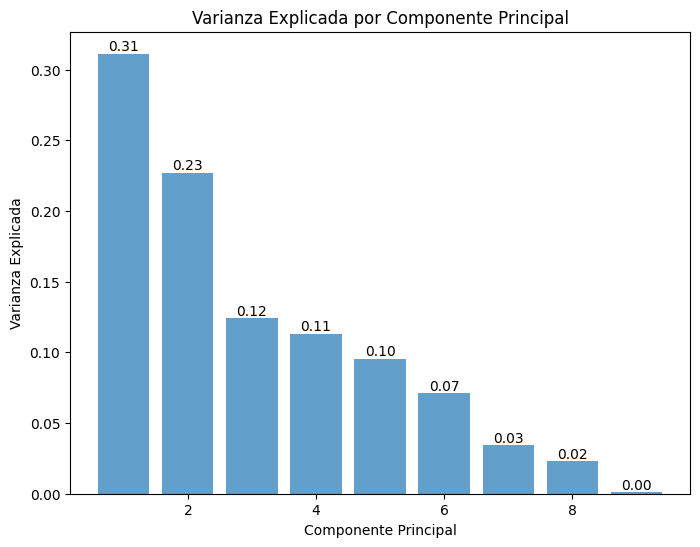

In [54]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Estandarizar los datos
scaler = StandardScaler()
df_1_scaled = scaler.fit_transform(df_1)

# Realizar el Análisis de Componentes Principales (PCA)
pca = PCA()
pca.fit(df_1_scaled)
explained_variance = pca.explained_variance_ratio_

# Graficar la varianza explicada por cada componente
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7)

# Agregar etiquetas a las barras
for i, var_exp in enumerate(explained_variance):
    plt.text(i + 1, var_exp, f"{var_exp:.2f}", ha='center', va='bottom')


plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada por Componente Principal')
plt.show()
# Diagrama de codo

In [55]:
##Muestra grfico de cargas en 2D para las variables incluidas
plt.scatter(loadings['PC1'],loadings['PC2'] )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Scatter plot Componentes principales')

# Establecer los límites de los ejes centrados en 0
plt.xlim(-1, 1)
plt.ylim(-1, 1)

# Agregar etiquetas a cada punto
for label, x, y in zip(loadings.index, loadings['PC1'], loadings['PC2']):
    plt.text(x, y, label, ha='center', va='top', color = 'dimgray')

# Agregar líneas punteadas en y = 0 y x = 0
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

# Mostrar el gráfico
plt.show()

NameError: name 'loadings' is not defined

## **Clustering**

In [56]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import scale
from sklearn.metrics import silhouette_score

In [57]:
modelo_kmeans = KMeans(n_clusters=10, n_init=25, random_state=123)
modelo_kmeans.fit(X=df_1_scaled)

KMeans(n_clusters=10, n_init=25, random_state=123)

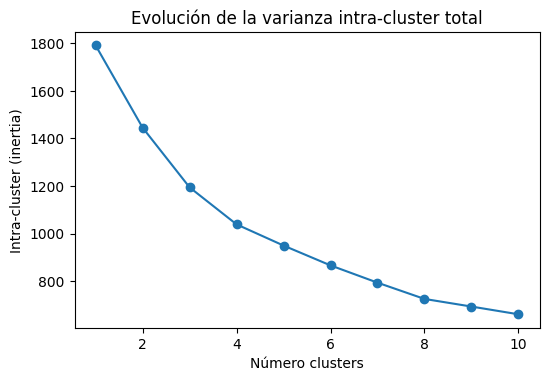

In [58]:
# Método elbow para identificar el número óptimo de clusters
# ==============================================================================
range_n_clusters = range(1, 11)
inertias_Kmeans = []

for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
                        n_clusters   = n_clusters,
                        n_init       = 20,
                        random_state = 123
                    )
    modelo_kmeans.fit(df_1_scaled)
    inertias_Kmeans.append(modelo_kmeans.inertia_)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, inertias_Kmeans, marker='o')
ax.set_title("Evolución de la varianza intra-cluster total")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Intra-cluster (inertia)');

In [59]:
print(inertias_Kmeans)

[1791.0000000000007, 1445.2991338486784, 1194.2765564630681, 1038.7176264477885, 949.6389257551044, 866.2226262671842, 793.6152281664774, 725.1930331066762, 693.159758014642, 660.6296792328242]


In [60]:
from sklearn.metrics import silhouette_score

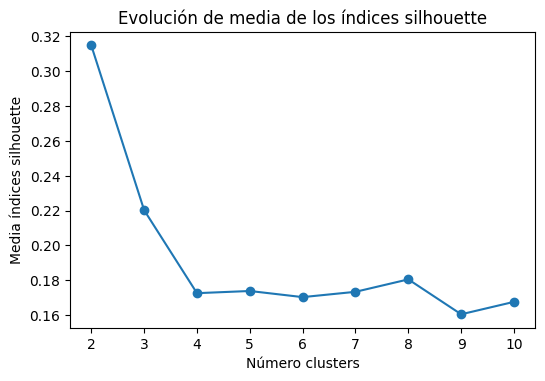

In [61]:
# Método silhouette para identificar el número óptimo de clusters
# ==============================================================================
range_n_clusters = range(2, 11)
valores_medios_silhouette_Kmeans = []

for n_clusters in range_n_clusters:
    modelo_kmeans = KMeans(
                        n_clusters   = n_clusters,
                        n_init       = 20,
                        random_state = 123
                    )
    cluster_labels = modelo_kmeans.fit_predict(df_1_scaled)
    silhouette_avg = silhouette_score(df_1_scaled, cluster_labels)
    valores_medios_silhouette_Kmeans.append(silhouette_avg)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, valores_medios_silhouette_Kmeans, marker='o')
ax.set_title("Evolución de media de los índices silhouette")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Media índices silhouette');

In [62]:
print(valores_medios_silhouette_Kmeans)

[0.31476865122075165, 0.22024972276911012, 0.17260022581830897, 0.1738486029330084, 0.1703363019935577, 0.17338086951783, 0.18051847836294144, 0.1604821572327185, 0.16762259649958702]


In [63]:
y_predict = modelo_kmeans.predict(X=df_1_scaled)

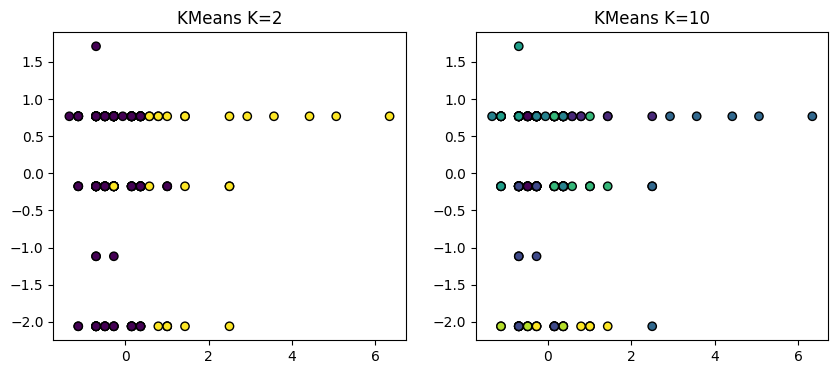

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

y_predict2 = KMeans(n_clusters=2, n_init=25, random_state=123).fit_predict(X=df_1_scaled)
ax[0].scatter(
        x = df_1_scaled[:, 0],
        y = df_1_scaled[:, 1],
        c = y_predict2,
        cmap='viridis',
        marker    = 'o',
        edgecolor = 'black'
    )
ax[0].set_title('KMeans K=2');

y_predict3 = KMeans(n_clusters=10, n_init=25, random_state=123).fit_predict(X=df_1_scaled)
ax[1].scatter(
        x = df_1_scaled[:, 0],
        y = df_1_scaled[:, 1],
        c = y_predict3,
        cmap='viridis',
        marker    = 'o',
        edgecolor = 'black'
    )
ax[1].set_title('KMeans K=10');

In [65]:
y_predict3

array([0, 6, 4, 8, 6, 0, 4, 6, 4, 5, 4, 9, 4, 5, 0, 8, 8, 4, 6, 6, 6, 4,
       1, 6, 6, 5, 1, 6, 5, 4, 9, 9, 5, 2, 0, 5, 2, 9, 8, 1, 4, 2, 8, 8,
       2, 4, 2, 9, 7, 1, 4, 3, 3, 3, 5, 2, 2, 4, 2, 2, 5, 2, 1, 3, 4, 3,
       1, 3, 9, 3, 3, 5, 5, 4, 4, 4, 4, 0, 0, 6, 1, 6, 6, 9, 1, 4, 1, 6,
       8, 8, 4, 4, 4, 4, 8, 0, 0, 4, 6, 4, 6, 4, 4, 0, 6, 4, 6, 0, 5, 0,
       4, 4, 6, 6, 2, 5, 8, 4, 5, 4, 6, 8, 8, 6, 9, 6, 4, 0, 0, 0, 6, 4,
       4, 6, 5, 0, 5, 6, 6, 1, 0, 0, 4, 4, 6, 4, 4, 5, 2, 5, 4, 6, 4, 2,
       5, 5, 2, 6, 6, 0, 5, 0, 6, 6, 6, 9, 5, 2, 0, 6, 5, 4, 2, 4, 1, 2,
       5, 0, 0, 4, 4, 6, 0, 2, 4, 2, 4, 2, 6, 8, 2, 2, 2, 4, 2, 2, 5, 0,
       9], dtype=int32)

In [66]:
ResultKmeans= pd.DataFrame(y_predict3)
ResultKmeans.rename(columns={0:"Cluster"},inplace=True)
ResultKmeans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Cluster  199 non-null    int32
dtypes: int32(1)
memory usage: 928.0 bytes


In [67]:
df_all = pd.concat([df,ResultKmeans],axis=1)
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No.                  199 non-null    int64  
 1   Nombre del Negocio   199 non-null    object 
 2   Localidad            199 non-null    object 
 3   Barrio               199 non-null    object 
 4   Tipo Tienda          199 non-null    object 
 5   CanalAtencion        199 non-null    object 
 6   CantidadReferencias  199 non-null    int64  
 7   NivelSocioEconómico  199 non-null    int64  
 8   CompraMes1           199 non-null    int64  
 9   Antigüedad           199 non-null    int64  
 10  CompraMes2           199 non-null    int64  
 11  MtsCuadrados         199 non-null    int64  
 12  Utilidad             199 non-null    float64
 13  QTrabajadores        199 non-null    int64  
 14  TiendasCompetencia   199 non-null    int64  
 15  Cluster              199 non-null    int

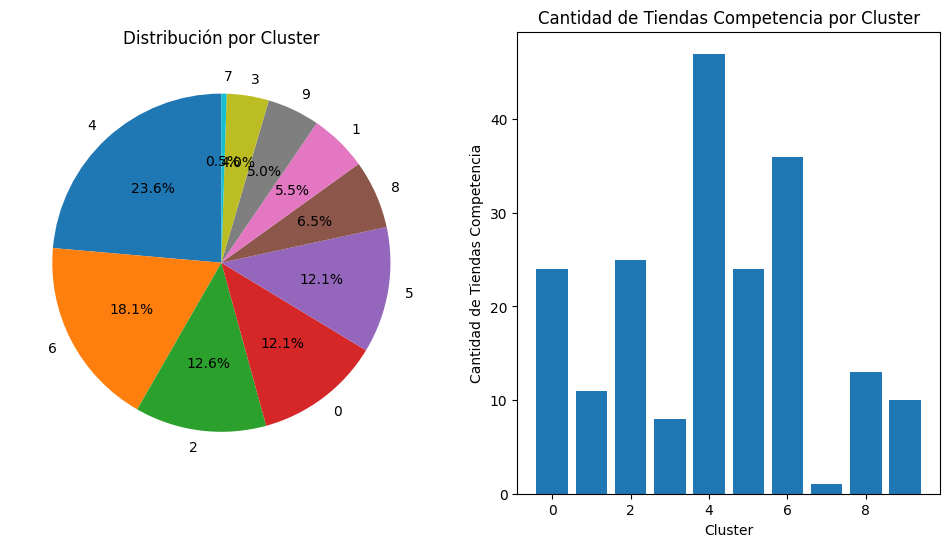

In [68]:
element_counts = df_all["Cluster"].value_counts()

# Crear una figura con dos subplots (uno para el gráfico circular y otro para el gráfico de barras)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico circular
ax1.pie(element_counts, labels=element_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title("Distribución por Cluster")

# Gráfico de barras

# Gráfico de barras
ax2.bar(element_counts.index, element_counts.values)
ax2.set_xlabel("Cluster")
ax2.set_ylabel("Cantidad de Tiendas Competencia")
ax2.set_title("Cantidad de Tiendas Competencia por Cluster")


# Mostrar la figura con ambos gráficos
plt.show()

In [69]:
pd.value_counts(df_all.Cluster)

,count
Cluster,
4,47
6,36
2,25
0,24
5,24
8,13
1,11
9,10
3,8


Perfil Cuantitativo por Cluster:
         TiendasCompetencia
Cluster                    
2                       1.8
4                       0.6
5                       2.5
6                       3.5

Perfil Cualitativo por Cluster:
Cluster  NivelSocioEconómico
2        3                     0.4
         4                     0.4
         1                     0.2
         2                     0.1
4        4                     0.6
         3                     0.4
5        4                     0.6
         3                     0.3
         5                     0.0
6        3                     0.5
         4                     0.4
         1                     0.1
Name: proportion, dtype: float64


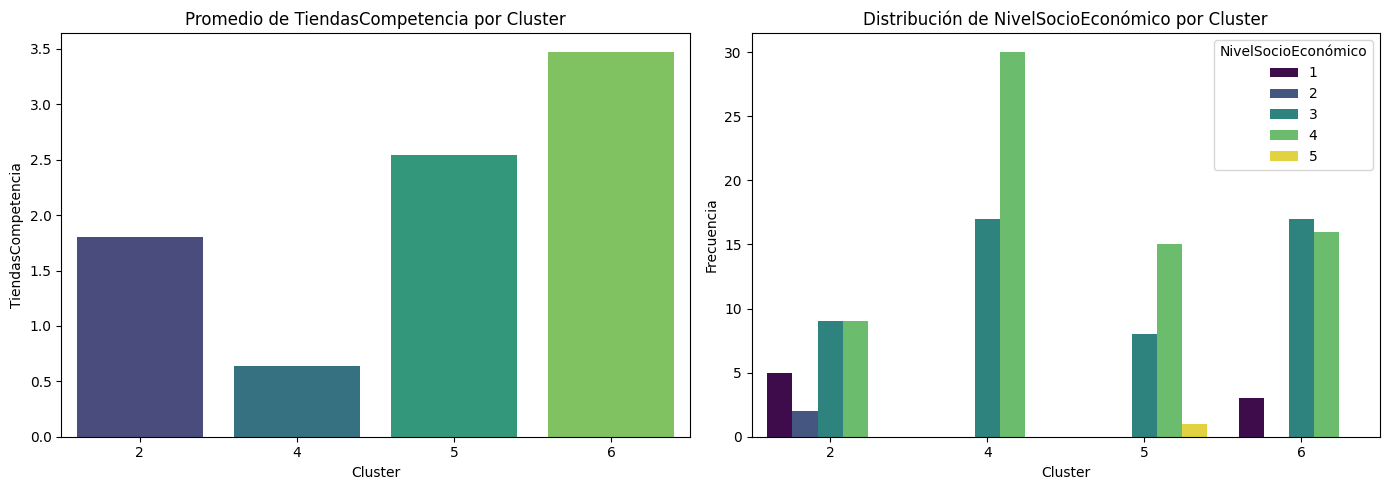

In [70]:
pd.set_option("display.float_format", lambda x: f"{x:.1f}")

# Definir los clusters específicos a analizar
clusters_especificos = [4, 6, 2, 5]  # Cambia estos valores según los clusters que desees incluir

# Filtrar el DataFrame por los clusters seleccionados
df_filtrado = df_all[df_all['Cluster'].isin(clusters_especificos)]

# Agrupar por cluster
Centroides = df_filtrado.groupby("Cluster")

# Perfil cuantitativo: promedio de la variable 'TiendasCompetencia'
averages = Centroides[['TiendasCompetencia']].mean()
print("Perfil Cuantitativo por Cluster:")
print(averages)

# Perfil cualitativo: distribución de 'NivelSocioEconómico' en cada cluster
perfil_cualitativo = Centroides['NivelSocioEconómico'].value_counts(normalize=True)
print("\nPerfil Cualitativo por Cluster:")
print(perfil_cualitativo)

# Visualización de los resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de perfil cuantitativo
sns.barplot(x=averages.index, y=averages['TiendasCompetencia'], ax=axes[0], palette='viridis')
axes[0].set_title('Promedio de TiendasCompetencia por Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('TiendasCompetencia')

# Gráfico de perfil cualitativo
sns.countplot(x='Cluster', hue='NivelSocioEconómico', data=df_filtrado, ax=axes[1], palette='viridis')
axes[1].set_title('Distribución de NivelSocioEconómico por Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [74]:
from sklearn.preprocessing import MinMaxScaler

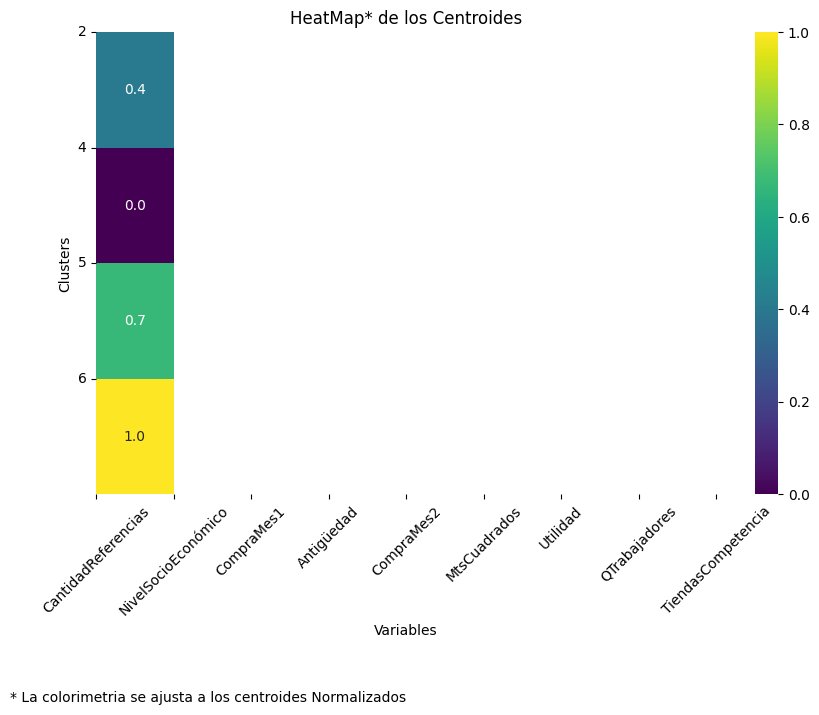

In [75]:
# Calcular los promedios originales
averages_original = Centroides[[
                'CantidadReferencias',
                'NivelSocioEconómico',
                'CompraMes1',
                'Antigüedad',
                'CompraMes2',
                'MtsCuadrados',
                'Utilidad',
                'QTrabajadores',
                'TiendasCompetencia'
    ]].mean()

# Normalizar los valores de las características
scaler = MinMaxScaler()
averages_scaled = scaler.fit_transform(averages)

# Crear un mapa de calor con colores personalizados para cada característica
plt.figure(figsize=(10, 6))
sns.heatmap(averages_scaled, annot=True, cmap="viridis", fmt=".1f")

# Personalizar las etiquetas de los ejes
feature_names = ['CantidadReferencias',
                'NivelSocioEconómico',
                'CompraMes1',
                'Antigüedad',
                'CompraMes2',
                'MtsCuadrados',
                'Utilidad',
                'QTrabajadores',
                'TiendasCompetencia']
plt.xticks(ticks=range(len(feature_names)), labels=feature_names, rotation=45, ha="center")
plt.yticks(ticks=range(len(averages.index)), labels=averages.index, rotation=0)

# Personalizar el gráfico (opcional)
plt.title("HeatMap* de los Centroides")
plt.xlabel("Variables")
plt.ylabel("Clusters")
plt.text(0.5, -0.45, "* La colorimetria se ajusta a los centroides Normalizados", transform=plt.gca().transAxes, ha="right")

# Mostrar el gráfico
plt.show()

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Calcular los promedios originales
averages_original = Centroides[[
                'CantidadReferencias',
                'NivelSocioEconómico',
                'CompraMes1',
                'Antigüedad',
                'CompraMes2',
                'MtsCuadrados',
                'Utilidad',
                'QTrabajadores',
                'TiendasCompetencia'
    ]].mean()

# Normalizar los valores de las características
scaler = MinMaxScaler()
averages_scaled = scaler.fit_transform(averages)

# Crear un mapa de calor con colores personalizados para cada característica
plt.figure(figsize=(10, 6))
sns.heatmap(averages_scaled, annot=averages_original, cmap="viridis", fmt=".1f")

# Personalizar las etiquetas de los ejes
feature_names = ["gdppc", "deathrate", "lifeE", "infantD", "birthsCR","fer"]
plt.xticks(ticks=range(len(feature_names)), labels=feature_names, rotation=45, ha="center")
plt.yticks(ticks=range(len(averages.index)), labels=averages.index, rotation=0)

# Personalizar el gráfico (opcional)
plt.title("HeatMap* de los Centroides")
plt.xlabel("Variables")
plt.ylabel("Clusters")
plt.text(0.5, -0.45, "* La colorimetria se ajusta a los centroides Normalizados", transform=plt.gca().transAxes, ha="right")

# Mostrar el gráfico
plt.show()

ValueError: `data` and `annot` must have same shape.

<Figure size 1000x600 with 0 Axes>

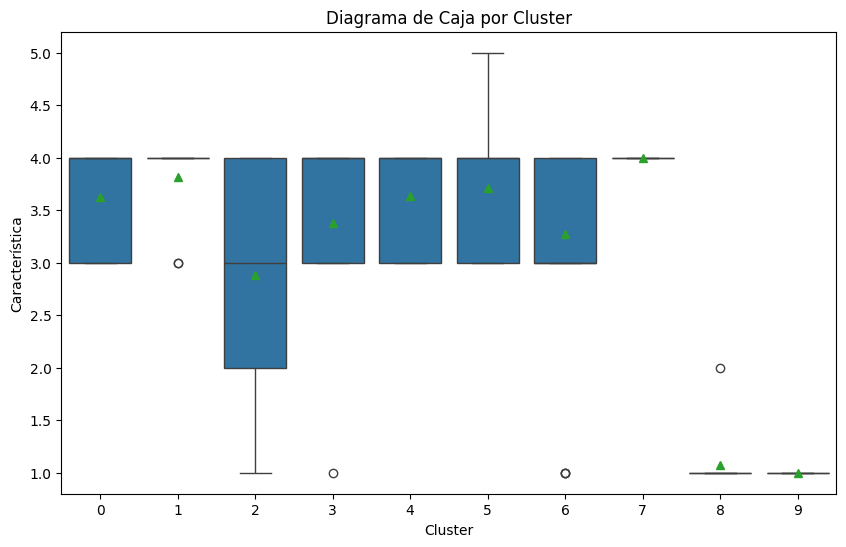

In [76]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='NivelSocioEconómico',showmeans=True,data=df_all)

# Personalizar el gráfico (opcional)
plt.title("Diagrama de Caja por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Característica")

# Mostrar el gráfico
plt.show()

In [ ]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No.                  199 non-null    int64  
 1   Nombre del Negocio   199 non-null    object 
 2   Localidad            199 non-null    object 
 3   Barrio               199 non-null    object 
 4   Tipo Tienda          199 non-null    object 
 5   CanalAtencion        199 non-null    object 
 6   CantidadReferencias  199 non-null    int64  
 7   NivelSocioEconómico  199 non-null    int64  
 8   CompraMes1           199 non-null    int64  
 9   Antigüedad           199 non-null    int64  
 10  CompraMes2           199 non-null    int64  
 11  MtsCuadrados         199 non-null    int64  
 12  Utilidad             199 non-null    float64
 13  QTrabajadores        199 non-null    int64  
 14  TiendasCompetencia   199 non-null    int64  
 15  Cluster              199 non-null    int

Haga un resumen con las variables Cualitativas Localidad, Atencion, TipoCanal (Tipo de tienda)


In [ ]:
import pandas as pd

cluster_groups = df_all.groupby('Cluster')

for cluster, group in cluster_groups:
    total_count = len(group)
    print(f"Cluster {cluster}:")
    for feature in ['Localidad']:
        feature_counts = group[feature].value_counts(normalize=True) * 100
        print(f"\t{feature}:")
        for category, percent in feature_counts.items():
            print(f"\t\t{category}: {percent:.2f}%")
    print("\n")


Cluster 0:
	Localidad:
		TEUSAQUILLO: 54.17%
		PUENTE ARANDA: 20.83%
		FONTIBON: 12.50%
		BARRIOS UNIDOS: 12.50%


Cluster 1:
	Localidad:
		TEUSAQUILLO: 63.64%
		FONTIBON: 18.18%
		PUENTE ARANDA: 18.18%


Cluster 2:
	Localidad:
		TEUSAQUILLO: 56.00%
		PUENTE ARANDA: 28.00%
		FONTIBON: 12.00%
		BARRIOS UNIDOS: 4.00%


Cluster 3:
	Localidad:
		TEUSAQUILLO: 62.50%
		FONTIBON: 37.50%


Cluster 4:
	Localidad:
		TEUSAQUILLO: 61.70%
		PUENTE ARANDA: 23.40%
		BARRIOS UNIDOS: 8.51%
		FONTIBON: 6.38%


Cluster 5:
	Localidad:
		TEUSAQUILLO: 70.83%
		PUENTE ARANDA: 16.67%
		BARRIOS UNIDOS: 8.33%
		FONTIBON: 4.17%


Cluster 6:
	Localidad:
		TEUSAQUILLO: 50.00%
		PUENTE ARANDA: 25.00%
		FONTIBON: 13.89%
		BARRIOS UNIDOS: 11.11%


Cluster 7:
	Localidad:
		TEUSAQUILLO: 100.00%


Cluster 8:
	Localidad:
		FONTIBON: 46.15%
		TEUSAQUILLO: 30.77%
		PUENTE ARANDA: 23.08%


Cluster 9:
	Localidad:
		FONTIBON: 40.00%
		TEUSAQUILLO: 40.00%
		PUENTE ARANDA: 20.00%




In [ ]:
import pandas as pd

cluster_groups = df_all.groupby('Cluster')

for cluster, group in cluster_groups:
    total_count = len(group)
    print(f"Cluster {cluster}:")
    for feature in ['CanalAtencion']:
        feature_counts = group[feature].value_counts(normalize=True) * 100
        print(f"\t{feature}:")
        for category, percent in feature_counts.items():
            print(f"\t\t{category}: {percent:.2f}%")
    print("\n")

Cluster 0:
	CanalAtencion:
		Vendedor: 91.67%
		Telemercadeo: 8.33%


Cluster 1:
	CanalAtencion:
		Vendedor: 81.82%
		Telemercadeo: 18.18%


Cluster 2:
	CanalAtencion:
		Vendedor: 92.00%
		Mercaderista: 8.00%


Cluster 3:
	CanalAtencion:
		Mercaderista: 50.00%
		Vendedor: 37.50%
		Gerente de Ventas: 12.50%


Cluster 4:
	CanalAtencion:
		Vendedor: 78.72%
		Telemercadeo: 17.02%
		Mercaderista: 4.26%


Cluster 5:
	CanalAtencion:
		Vendedor: 95.83%
		Mercaderista: 4.17%


Cluster 6:
	CanalAtencion:
		Vendedor: 86.11%
		Telemercadeo: 13.89%


Cluster 7:
	CanalAtencion:
		Mercaderista: 100.00%


Cluster 8:
	CanalAtencion:
		Vendedor: 84.62%
		Mercaderista: 7.69%
		Telemercadeo: 7.69%


Cluster 9:
	CanalAtencion:
		Vendedor: 80.00%
		Gerente de Ventas: 10.00%
		Telemercadeo: 10.00%




In [ ]:
import pandas as pd

cluster_groups = df_all.groupby('Cluster')

for cluster, group in cluster_groups:
    total_count = len(group)
    print(f"Cluster {cluster}:")
    for feature in ['Tipo Tienda']:
        feature_counts = group[feature].value_counts(normalize=True) * 100
        print(f"\t{feature}:")
        for category, percent in feature_counts.items():
            print(f"\t\t{category}: {percent:.2f}%")
    print("\n")

Cluster 0:
	Tipo Tienda:
		Tienda de Barrio: 25.00%
		Panaderia/Pasteleria: 16.67%
		Carniceria/Pesqueria/Fama : 12.50%
		Pizzerias : 12.50%
		Salsamentaria/Delikatessen : 12.50%
		Tienda/Cafeteria : 12.50%
		Comidas Rapidas: 4.17%
		Comidas rapidas: 4.17%


Cluster 1:
	Tipo Tienda:
		Minimercado: 27.27%
		Panaderia/Pasteleria: 27.27%
		Comidas Rapidas: 18.18%
		Carniceria/Pesqueria/Fama : 9.09%
		Tienda de Barrio: 9.09%
		Tienda/Cafeteria : 9.09%


Cluster 2:
	Tipo Tienda:
		Tienda/Cafeteria : 32.00%
		Comidas Rapidas: 20.00%
		Minimercado: 20.00%
		Tienda de Barrio: 20.00%
		Pizzerias : 4.00%
		Comidas rapidas: 4.00%


Cluster 3:
	Tipo Tienda:
		Minimercado: 100.00%


Cluster 4:
	Tipo Tienda:
		Panaderia/Pasteleria: 21.28%
		Pizzerias : 17.02%
		Carniceria/Pesqueria/Fama : 14.89%
		Tienda de Barrio: 14.89%
		Tienda/Cafeteria : 12.77%
		Comidas Rapidas: 6.38%
		Minimercado: 6.38%
		Supermercados : 4.26%
		Salsamentaria/Delikatessen : 2.13%


Cluster 5:
	Tipo Tienda:
		Tienda de Barrio

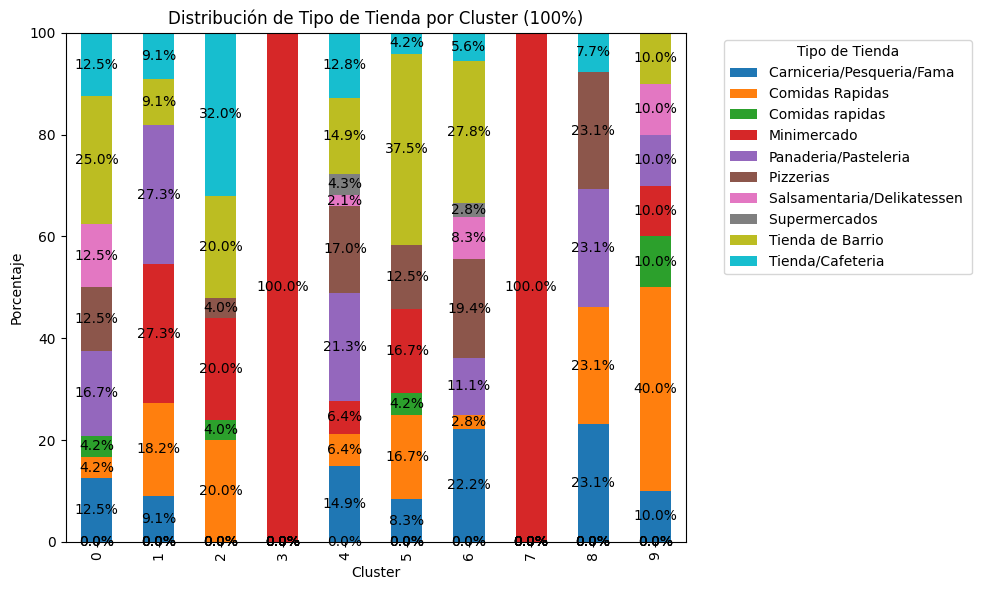

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Distribución por Cluster y Continente

# 1. Calcular porcentajes por cluster y continente
cluster_continente = df_all.groupby(['Cluster', 'Tipo Tienda']).size().unstack(fill_value=0)
cluster_continente_porcentaje = cluster_continente.apply(lambda x: x / x.sum() * 100, axis=1)

# 2. Crear el gráfico de barras agrupadas
ax = cluster_continente_porcentaje.plot(kind='bar', stacked=True, figsize=(10, 6))

# 3. Agregar etiquetas a las barras
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2), ha='center', va='center')

# 4. Personalizar el gráfico
plt.title('Distribución de Tipo de Tienda por Cluster (100%)')
plt.xlabel('Cluster')
plt.ylabel('Porcentaje')
plt.ylim(0, 100)  # Establecer límite del eje y en 100%

# 5. Mostrar la leyenda
plt.legend(title='Tipo de Tienda', bbox_to_anchor=(1.05, 1), loc='upper left')  # Mostrar leyenda fuera del gráfico

# 6. Mostrar el gráfico
plt.tight_layout()  # Ajustar diseño para evitar etiquetas cortadas
plt.show()

## **Clustering + PCA**

In [ ]:
# Estandarizar los datos
scaler = StandardScaler()
df_1_scaled = scaler.fit_transform(df_1)

# Realizar el Análisis de Componentes Principales (PCA)
pca = PCA(n_components=2)
Y = pca.fit_transform(df_1_scaled)

ResultPCA= pd.DataFrame(Y)
ResultPCA.rename(columns={0:"PC1",1:"PC2"},inplace=True)

df_all = pd.concat([df_all,ResultPCA],axis=1)
df_all.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No.                  199 non-null    int64  
 1   Nombre del Negocio   199 non-null    object 
 2   Localidad            199 non-null    object 
 3   Barrio               199 non-null    object 
 4   Tipo Tienda          199 non-null    object 
 5   CanalAtencion        199 non-null    object 
 6   CantidadReferencias  199 non-null    int64  
 7   NivelSocioEconómico  199 non-null    int64  
 8   CompraMes1           199 non-null    int64  
 9   Antigüedad           199 non-null    int64  
 10  CompraMes2           199 non-null    int64  
 11  MtsCuadrados         199 non-null    int64  
 12  Utilidad             199 non-null    float64
 13  QTrabajadores        199 non-null    int64  
 14  TiendasCompetencia   199 non-null    int64  
 15  Cluster              199 non-null    int

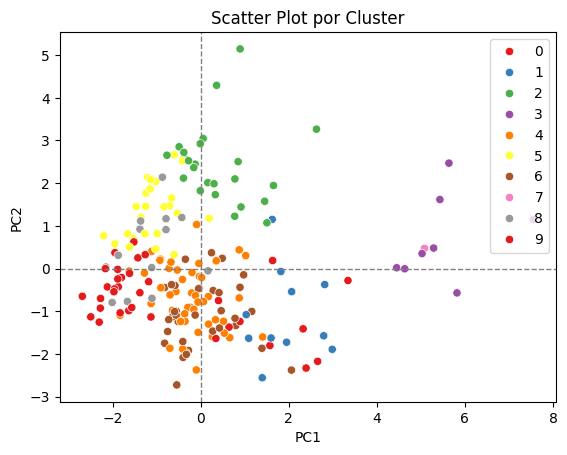

In [ ]:
# Crea el scatter plot con colores según la columna "Localidad"
sns.scatterplot(data=df_all, x='PC1', y='PC2', hue='Cluster', palette='Set1')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Scatter Plot por Cluster')
# Agrega las rectas y=0 y x=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)

plt.legend()  # Muestra la leyenda con los colores correspondientes
plt.show()

## K-Medoides

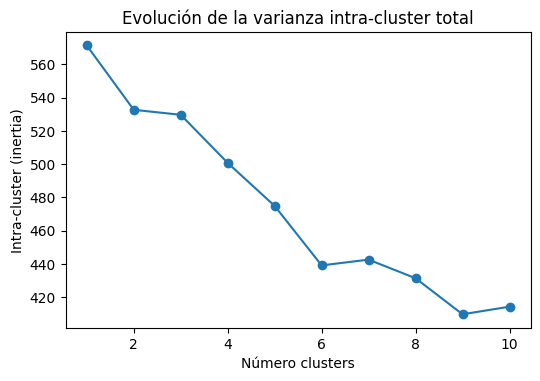

In [77]:
# Método elbow para identificar el número óptimo de clusters
# ==============================================================================
range_n_clusters = range(1, 11)
inertias_Kmedoides = []

for n_clusters in range_n_clusters:

    kmedoids = KMedoids(n_clusters=n_clusters,
                        random_state=123)
    kmedoids.fit(df_1_scaled)
    inertias_Kmedoides.append(kmedoids.inertia_)  ## La inercia es una medida de cuánto se separan los puntos dentro de cada cluster. Es la suma de las distancias al cuadrado entre cada punto y el centroide (o medoide) de su cluster

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, inertias_Kmedoides, marker='o')
ax.set_title("Evolución de la varianza intra-cluster total")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Intra-cluster (inertia)');

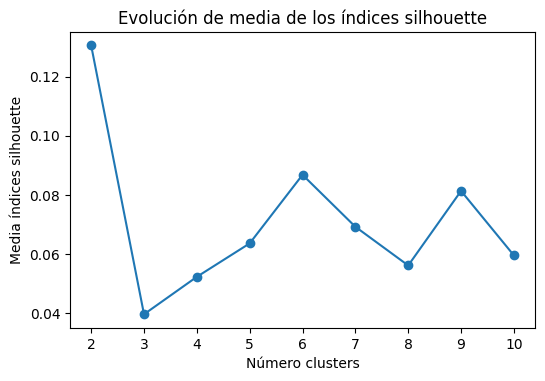

In [84]:
# Método silhouette para identificar el número óptimo de clusters
# ==============================================================================
range_n_clusters = range(2, 11)
valores_medios_silhouette_Kmedoides = []

for k in range_n_clusters:
    kmedoids = KMedoids(n_clusters=k,
                        random_state=42)
    cluster_labels = kmedoids.fit_predict(df_1_scaled)
    silhouette_avg = silhouette_score(df_1_scaled, cluster_labels)
    valores_medios_silhouette_Kmedoides.append(silhouette_avg)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, valores_medios_silhouette_Kmedoides, marker='o')
ax.set_title("Evolución de media de los índices silhouette")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Media índices silhouette');



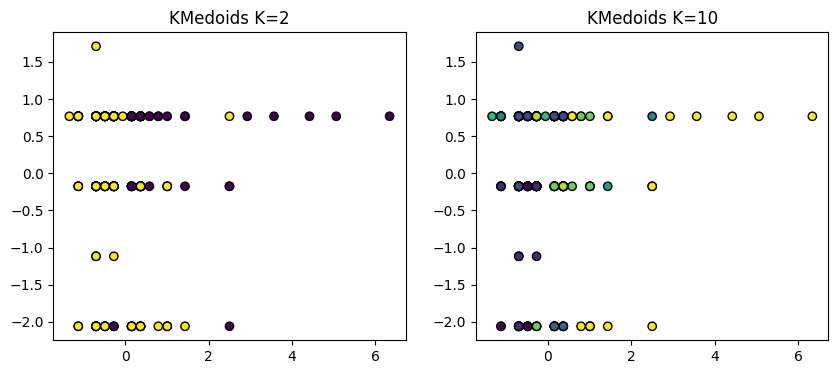

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

y_predict4 = KMedoids(n_clusters=2, random_state=123).fit_predict(X=df_1_scaled)
ax[0].scatter(
        x = df_1_scaled[:, 0],
        y = df_1_scaled[:, 1],
        c = y_predict4,
        cmap='viridis',
        marker    = 'o',
        edgecolor = 'black'
    )
ax[0].set_title('KMedoids K=2');

y_predict5 = KMedoids(n_clusters=10, random_state=123).fit_predict(X=df_1_scaled)
ax[1].scatter(
        x = df_1_scaled[:, 0],
        y = df_1_scaled[:, 1],
        c = y_predict5,
        cmap='viridis',
        marker    = 'o',
        edgecolor = 'black'
    )
ax[1].set_title('KMedoids K=10');

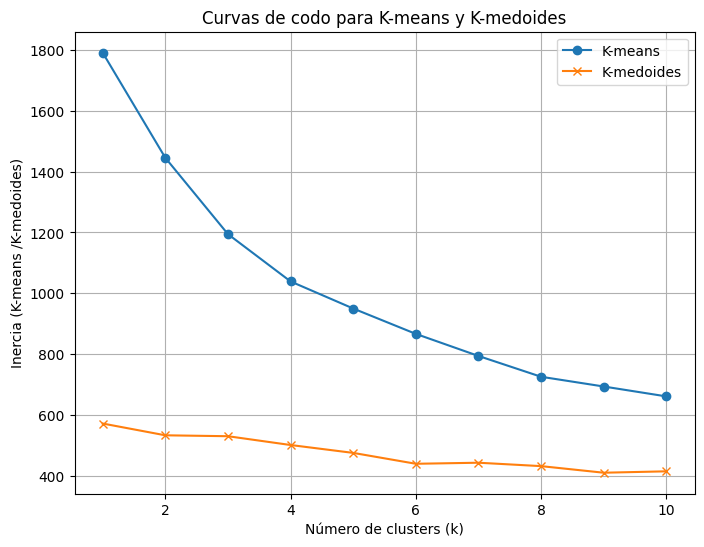

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertias_Kmeans, marker='o', label='K-means')
plt.plot(range(1, 11), inertias_Kmedoides, marker='x', label='K-medoides')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (K-means /K-medoides)')
plt.title('Curvas de codo para K-means y K-medoides')
plt.legend()
plt.grid()
plt.show()

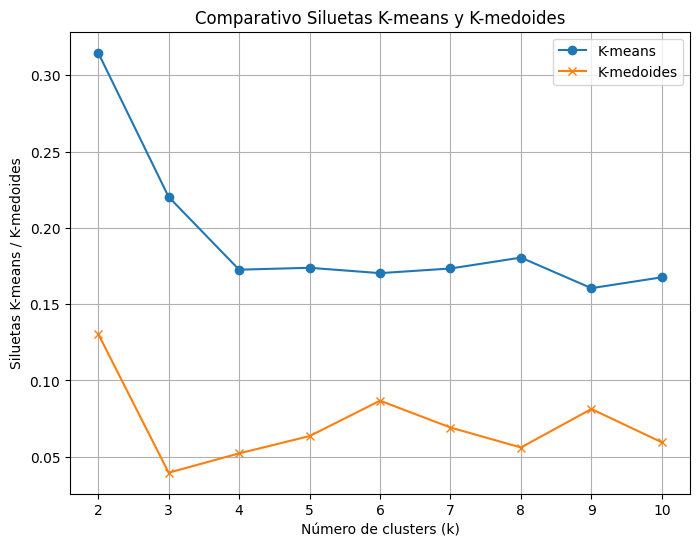

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), valores_medios_silhouette_Kmeans, marker='o', label='K-means')
plt.plot(range(2, 11), valores_medios_silhouette_Kmedoides, marker='x', label='K-medoides')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Siluetas K-means / K-medoides')
plt.title('Comparativo Siluetas K-means y K-medoides')
plt.legend()
plt.grid()
plt.show()



## Clustering Jerárquico

In [80]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.preprocessing import scale
from sklearn.metrics import silhouette_score

In [81]:
modelo_hclust = AgglomerativeClustering(
                            metric = 'euclidean',
                            linkage  = 'ward',  # 'ward','complete', 'single'
                            distance_threshold = 0,
                            n_clusters         = None
                        )
modelo_hclust.fit(X=df_1_scaled)

AgglomerativeClustering(distance_threshold=0, n_clusters=None)

In [82]:
## Funcion para crear en dendrograma a partir de las distancias y la iteración e ingreso de nodos hijos/terminales a un nuevo grupo (o no)
def plot_dendrogram(model, **kwargs):
    '''
    Esta función extrae la información de un modelo AgglomerativeClustering
    y representa su dendograma con la función dendogram de scipy.cluster.hierarchy
    '''

    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)

    # Plot
    dendrogram(linkage_matrix, **kwargs)

Text(0.5, 1.0, 'Dendrograma')

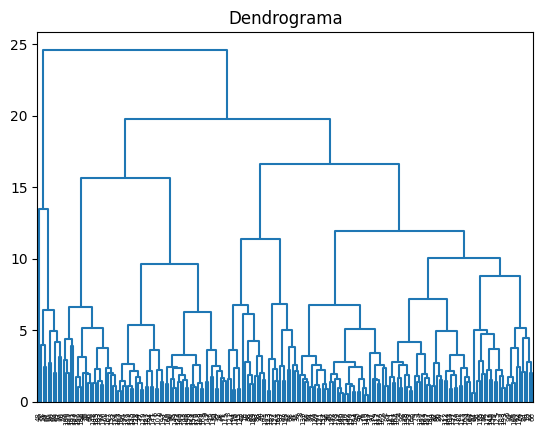

In [ ]:
plot_dendrogram(modelo_hclust, color_threshold=0)
plt.title('Dendrograma')


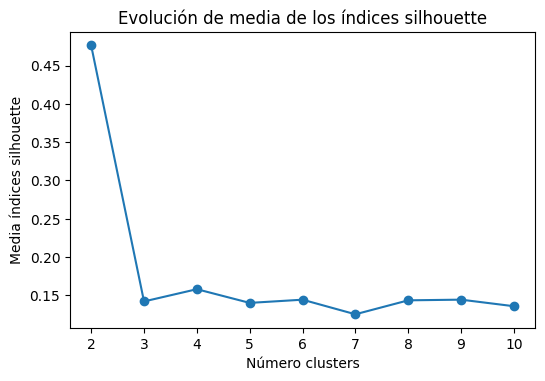

In [83]:
# Método silhouette para identificar el número óptimo de clusters
# ==============================================================================
range_n_clusters = range(2, 11)
valores_medios_silhouette_Jerarquico = []

for n_clusters in range_n_clusters:
    modelo = AgglomerativeClustering(
                    metric   = 'euclidean',
                    linkage    = 'ward',
                    n_clusters = n_clusters
             )

    cluster_labels = modelo.fit_predict(df_1_scaled)
    silhouette_avg = silhouette_score(df_1_scaled, cluster_labels)
    valores_medios_silhouette_Jerarquico.append(silhouette_avg)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.84))
ax.plot(range_n_clusters, valores_medios_silhouette_Jerarquico, marker='o')
ax.set_title("Evolución de media de los índices silhouette")
ax.set_xlabel('Número clusters')
ax.set_ylabel('Media índices silhouette');


In [ ]:
print(valores_medios_silhouette_Jerarquico)

[0.47628844669662324, 0.14200649610061997, 0.1579961489406598, 0.14010609454797832, 0.14428675689934745, 0.12523174771333762, 0.14345171026585507, 0.14433553309486893, 0.13576488499493605]


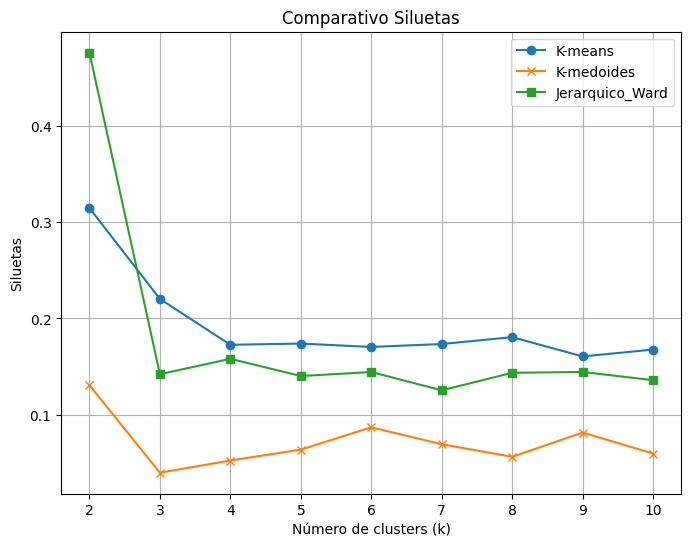

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), valores_medios_silhouette_Kmeans, marker='o', label='K-means')
plt.plot(range(2, 11), valores_medios_silhouette_Kmedoides, marker='x', label='K-medoides')
plt.plot(range(2, 11), valores_medios_silhouette_Jerarquico, marker='s', label='Jerarquico_Ward')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Siluetas')
plt.title('Comparativo Siluetas')
plt.legend()
plt.grid()
plt.show()

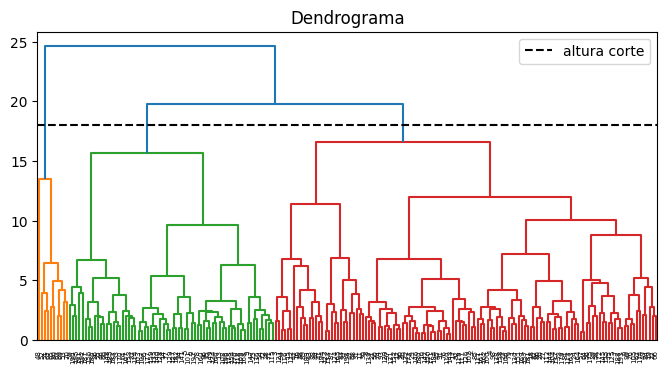

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
altura_corte = 18
plot_dendrogram(modelo_hclust, color_threshold=altura_corte, ax=ax)
ax.set_title("Dendrograma")
ax.axhline(y=altura_corte, c = 'black', linestyle='--', label='altura corte')
ax.legend();

In [ ]:
modelo_hclust_def = AgglomerativeClustering(
                            metric = 'euclidean',
                            linkage  = 'ward',
                            n_clusters = 3
                     )
modelo_hclust_def.fit(X=df_1_scaled)

AgglomerativeClustering(n_clusters=3)

In [ ]:
y_predict5 = AgglomerativeClustering(
                            metric = 'euclidean',
                            linkage  = 'ward',
                            n_clusters = 3).fit_predict(X=df_1_scaled)



In [ ]:
y_predict5

array([2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 2, 0, 1, 0, 0, 1, 1, 1, 2, 2, 0, 0, 0, 2, 2, 2, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 2, 2, 2,
       0, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 0,
       0, 0, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 2,
       2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 0, 2, 0, 0, 0, 0, 0,
       2, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 0, 0, 2, 2, 2,
       0])

In [ ]:
ResultJerar= pd.DataFrame(y_predict5)  ##Convierto a pd
ResultJerar.rename(columns={0:"ClusterJerar"},inplace=True)
ResultJerar.info()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ClusterJerar  199 non-null    int64
dtypes: int64(1)
memory usage: 1.7 KB


In [ ]:
df_all = pd.concat([df_all,ResultJerar],axis=1)
df_all.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No.                  199 non-null    int64  
 1   Nombre del Negocio   199 non-null    object 
 2   Localidad            199 non-null    object 
 3   Barrio               199 non-null    object 
 4   Tipo Tienda          199 non-null    object 
 5   CanalAtencion        199 non-null    object 
 6   CantidadReferencias  199 non-null    int64  
 7   NivelSocioEconómico  199 non-null    int64  
 8   CompraMes1           199 non-null    int64  
 9   Antigüedad           199 non-null    int64  
 10  CompraMes2           199 non-null    int64  
 11  MtsCuadrados         199 non-null    int64  
 12  Utilidad             199 non-null    float64
 13  QTrabajadores        199 non-null    int64  
 14  TiendasCompetencia   199 non-null    int64  
 15  Cluster              199 non-null    int

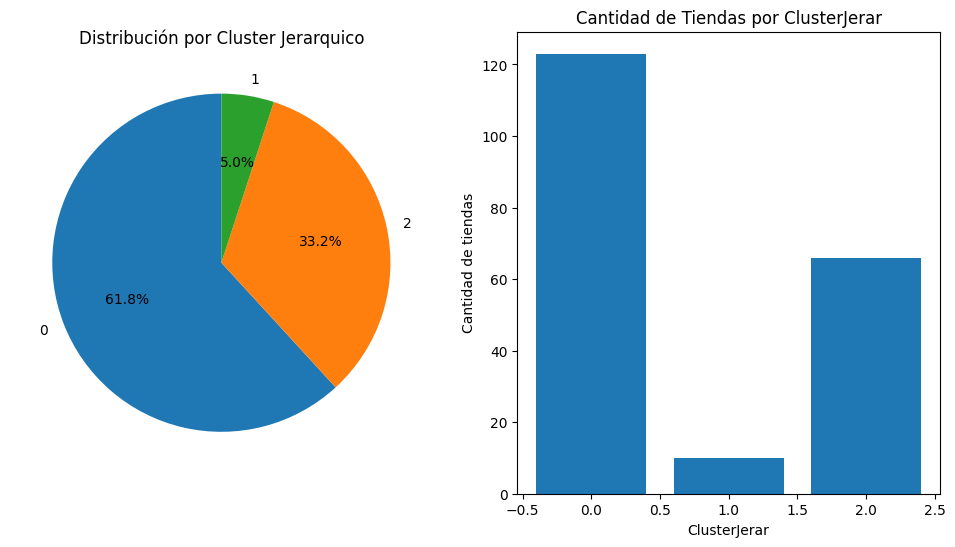

In [ ]:
element_counts = df_all["ClusterJerar"].value_counts()

# Crear una figura con dos subplots (uno para el gráfico circular y otro para el gráfico de barras)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico circular
ax1.pie(element_counts, labels=element_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title("Distribución por Cluster Jerarquico")

# Gráfico de barras
ax2.bar(element_counts.index, element_counts.values)
ax2.set_xlabel("ClusterJerar")
ax2.set_ylabel("Cantidad de tiendas")
ax2.set_title("Cantidad de Tiendas por ClusterJerar")


# Mostrar la figura con ambos gráficos
plt.show()

In [ ]:
pd.value_counts(df_all.ClusterJerar)


,count
ClusterJerar,
0,123
2,66
1,10


In [ ]:
# Matriz/Tabla cruzada para comprobar diferencias en volúmenes de registros entre K-Means y Jerárquico
pd.crosstab(df_all.Cluster,df_all.ClusterJerar)


ClusterJerar,0,1,2
Cluster,,,
0,1,0,23
1,10,1,0
2,7,0,18
3,0,8,0
4,45,0,2
5,1,0,23
6,36,0,0
7,0,1,0
8,13,0,0
